# Single-room training (dataset setup)

This notebook builds the **data pipeline for one AcousticRooms room**: all source–receiver pairs in that room are grouped into a PyTorch `Dataset` with **everything preloaded into RAM** (waveforms, targets, scaled geometry, depth maps). Sections 1–6 prepare data and a smoke-test batch; **section 7** trains `STFTModel` from `icassp_lightning_components.py` (same architecture as `train_edcModelPytorchLighteningICASSP_V1.py`) on that single-room split.

**Steps:** optional — set `ROOM_TYPE` / `ROOM_ID` to folder names that exist on disk (case-sensitive). If that pair is missing, section 3 automatically uses the **first** room from the manifest table.

## 1. Configuration

In [1]:
import os
import re
import json

import numpy as np
import pandas as pd
import soundfile as sf
from scipy.signal import stft, resample
from sklearn.preprocessing import MinMaxScaler

import torch
from torch.utils.data import Dataset, DataLoader

# ------------------ Paths ------------------
DATASET_ROOT = os.environ.get("ACOUSTIC_ROOMS_ROOT", "/mnt/code/code/AcousticRooms")
IR_BASE_PATH = os.path.join(DATASET_ROOT, "single_channel_ir")
METADATA_PATH = os.path.join(DATASET_ROOT, "metadata")
DEPTH_MAP_BASE_PATH = os.path.join(DATASET_ROOT, "depth_map")

# Pick exactly one room (must match folder names under IR_BASE_PATH, case-sensitive).
# If this pair is missing from the manifest, the next cell falls back to the first room.
ROOM_TYPE = "classroom"
ROOM_ID = "room_01"

# Match training defaults
SAMPLE_RATE = 16000
WAVEFORM_LENGTH = 16000
COORD_FEATURE_DIM = 12  # build_room_feature_row: no dist in X (dist_m separate)
N_REF_RIRS = 3
REF_RIR_FEAT_DIM = 6
USE_REFERENCE_RIRS = True  # False: skip loading reference-RIR features; model ignores ref-input path

USE_RAW_WAVEFORMS = True  # True: peak-normalized waveform target; False: log1p STFT magnitude vector
USE_DEPTH_MAP = True
STRICT_DEPTH_MAP = True  # if True, skip pairs with missing depth when building bounds / dataset

# STFT params (only if USE_RAW_WAVEFORMS is False)
STFT_N_FFT = 1024
STFT_HOP = 512

# Workers only help CPU transforms here; data is already in memory — 0 is typical.
DATALOADER_NUM_WORKERS = 0
BATCH_SIZE = 8

TRAIN_FRACTION = 0.9  # split pairs inside this room only; set to 1.0 to use all pairs for "train"
SPLIT_SEED = 42

# Train subset only (does **not** change the validation split or val_ds).
# None = use every pair in the train split; set an int to train on at most that many pairs.
MAX_TRAIN_SAMPLES = None

## 2. Helpers (aligned with `train_edcModelPytorchLighteningICASSP_V1.py`)

In [2]:
def load_acoustic_rooms_rows(ir_base: str, meta_base: str) -> pd.DataFrame:
    rows = []
    for room_type in sorted(os.listdir(ir_base)):
        room_type_path = os.path.join(ir_base, room_type)
        if not os.path.isdir(room_type_path):
            continue
        for room_id in sorted(os.listdir(room_type_path)):
            room_path = os.path.join(room_type_path, room_id)
            if not os.path.isdir(room_path):
                continue
            for file_name in sorted(os.listdir(room_path)):
                if not file_name.endswith("_hybrid_IR.wav"):
                    continue
                stem = file_name.replace("_hybrid_IR.wav", "")
                rir_path = os.path.join(room_path, file_name)
                json_path = os.path.join(meta_base, room_type, room_id, f"{stem}.json")
                if not os.path.exists(json_path):
                    continue
                with open(json_path, "r") as f:
                    meta = json.load(f)
                rows.append(
                    {
                        "room_type": room_type,
                        "room_id": room_id,
                        "stem": stem,
                        "rir_path": rir_path,
                        "src_x": meta["src_loc"][0],
                        "src_y": meta["src_loc"][1],
                        "src_z": meta["src_loc"][2],
                        "rec_x": meta["rec_loc"][0],
                        "rec_y": meta["rec_loc"][1],
                        "rec_z": meta["rec_loc"][2],
                    }
                )
    return pd.DataFrame(rows)


def compute_room_dimensions(df: pd.DataFrame) -> dict:
    room_dims = {}
    for (room_type, room_id), group in df.groupby(["room_type", "room_id"]):
        xs = np.concatenate([group["src_x"].values, group["rec_x"].values])
        ys = np.concatenate([group["src_y"].values, group["rec_y"].values])
        zs = np.concatenate([group["src_z"].values, group["rec_z"].values])
        length = float(np.max(xs) - np.min(xs))
        width = float(np.max(ys) - np.min(ys))
        height = float(np.max(zs) - np.min(zs))
        room_dims[(room_type, room_id)] = (length, width, height)
    return room_dims


def extract_rir_acoustic_features(rir, sample_rate=16000):
    rir = np.array(rir, dtype=np.float32)
    window = sample_rate // 100
    n_windows = len(rir) // window
    if n_windows < 5:
        t60 = 0.4
    else:
        windows = rir[: n_windows * window].reshape(n_windows, window)
        energy = np.mean(windows**2, axis=1)
        peak_e = np.max(energy) + 1e-10
        log_e = np.log(energy / peak_e + 1e-10)
        t = np.arange(n_windows) * (window / sample_rate)
        slope = np.polyfit(t, log_e, 1)[0]
        t60 = float(np.clip(-6.9078 / (slope - 1e-10), 0.1, 5.0))
    peak_idx = int(np.abs(rir).argmax())
    direct_win = max(1, int(0.005 * sample_rate))
    direct_energy = float(np.sum(rir[peak_idx : peak_idx + direct_win] ** 2))
    reverb_energy = float(np.sum(rir[peak_idx + direct_win :] ** 2) + 1e-10)
    drr = float(10 * np.log10(direct_energy / reverb_energy + 1e-10))
    drr = float(np.clip(drr, -20, 20))
    early_cutoff = int(0.05 * sample_rate)
    early_energy = float(np.sum(rir[:early_cutoff] ** 2))
    total_energy = float(np.sum(rir**2) + 1e-10)
    early_ratio = float(np.clip(early_energy / total_energy, 0, 1))
    rms = float(np.sqrt(np.mean(rir**2)))
    peak_amp = float(np.abs(rir).max())
    energy_per_sample = rir**2
    centroid = float(np.sum(np.arange(len(rir)) * energy_per_sample) / (np.sum(energy_per_sample) + 1e-10)) / sample_rate
    centroid = float(np.clip(centroid, 0, 1))
    return np.array([t60, drr, early_ratio, rms, peak_amp, centroid], dtype=np.float32)


def load_preprocess_rir(rir_path: str, target_len: int, target_sr: int) -> tuple[np.ndarray, int]:
    rir, sample_rate = sf.read(rir_path)
    sample_rate = int(sample_rate)
    if rir.ndim > 1:
        rir = rir[:, 0]
    rir = np.asarray(rir, dtype=np.float32).flatten()
    if sample_rate != target_sr:
        n_new = int(round(len(rir) * float(target_sr) / float(sample_rate)))
        rir = resample(rir, n_new).astype(np.float32)
        sample_rate = target_sr
    onset = int(np.abs(rir).argmax())
    lead_in = max(0, onset - 10)
    rir = rir[lead_in:]
    rir = rir[:target_len]
    if len(rir) < target_len:
        rir = np.pad(rir, (0, target_len - len(rir)), mode="constant")
    return np.asarray(rir, dtype=np.float32), sample_rate


def compute_geometric_distance_m(row: pd.Series) -> float:
    return float(
        np.sqrt(
            (row["src_x"] - row["rec_x"]) ** 2
            + (row["src_y"] - row["rec_y"]) ** 2
            + (row["src_z"] - row["rec_z"]) ** 2
        )
    )


def build_room_feature_row(row: pd.Series, room_dims: dict, ref_sr: int) -> np.ndarray:
    L, W, H = room_dims[(row["room_type"], row["room_id"])]
    sx, sy, sz = float(row["src_x"]), float(row["src_y"]), float(row["src_z"])
    rx, ry, rz = float(row["rec_x"]), float(row["rec_y"]), float(row["rec_z"])
    dx, dy, dz = rx - sx, ry - sy, rz - sz
    return np.array([sx, sy, sz, rx, ry, rz, L, W, H, dx, dy, dz], dtype=np.float32)


def load_depth_numpy(row: pd.Series, depth_base: str, strict: bool) -> np.ndarray:
    receiver_match = re.search(r"_R(\d+)$", row["stem"])
    if receiver_match is None:
        raise ValueError(f"Cannot parse receiver index from stem: {row['stem']}")
    receiver_idx = int(receiver_match.group(1))
    depth_path = os.path.join(depth_base, row["room_type"], row["room_id"], f"{receiver_idx}.npy")
    if not os.path.exists(depth_path):
        if strict:
            raise FileNotFoundError(f"Depth map not found: {depth_path}")
        return np.zeros((1, 256, 512), dtype=np.float32)
    depth_raw = np.load(depth_path)
    depth_raw = np.asarray(depth_raw, dtype=np.float32)
    if depth_raw.ndim == 2:
        depth_map = depth_raw[np.newaxis, :, :]
    elif depth_raw.ndim == 3:
        if depth_raw.shape[0] in (1, 3):
            depth_map = depth_raw[:1, :, :]
        elif depth_raw.shape[-1] in (1, 3):
            depth_map = np.transpose(depth_raw, (2, 0, 1))[:1, :, :]
        else:
            raise ValueError(f"Unsupported depth map shape: {depth_raw.shape}")
    else:
        raise ValueError(f"Unsupported depth map ndim: {depth_raw.ndim}")
    return depth_map.astype(np.float32)


def scan_depth_global_bounds(df: pd.DataFrame, depth_base: str, strict: bool) -> tuple[float, float]:
    dmin, dmax = np.inf, -np.inf
    for _, row in df.iterrows():
        try:
            dm = load_depth_numpy(row, depth_base, strict)
        except FileNotFoundError:
            continue
        dmin = min(dmin, float(dm.min()))
        dmax = max(dmax, float(dm.max()))
    if not np.isfinite(dmin) or not np.isfinite(dmax):
        raise RuntimeError("No depth arrays could be loaded; check DEPTH_MAP_BASE_PATH and STRICT_DEPTH_MAP.")
    return float(dmin), float(dmax)


def build_stft_log_flat_target(
    rir: np.ndarray,
    sample_rate: int,
    waveform_length: int,
    stft_n_fft: int,
    stft_hop: int,
) -> np.ndarray:
    stft_time_frames = int(np.ceil(waveform_length / float(stft_hop)))
    stft_freq_bins = stft_n_fft // 2 + 1
    try:
        _f, _t, Zxx = stft(
            rir,
            fs=sample_rate,
            nperseg=stft_n_fft,
            noverlap=stft_n_fft - stft_hop,
            boundary=None,
        )
        mag = np.abs(Zxx)
        if mag.shape[1] > stft_time_frames:
            mag = mag[:, :stft_time_frames]
        elif mag.shape[1] < stft_time_frames:
            mag = np.pad(mag, ((0, 0), (0, stft_time_frames - mag.shape[1])), mode="constant")
        mag = np.log1p(mag).astype(np.float32)
        return mag.reshape(-1).astype(np.float32)
    except Exception:
        mag = np.zeros((stft_freq_bins, stft_time_frames), dtype=np.float32)
        return mag.reshape(-1).astype(np.float32)


def stream_stft_target_bounds(df: pd.DataFrame, waveform_len: int, target_sr: int, stft_n_fft: int, stft_hop: int):
    gmin, gmax = np.inf, -np.inf
    for _, row in df.iterrows():
        try:
            rir, sr = load_preprocess_rir(row["rir_path"], waveform_len, target_sr)
            flat = build_stft_log_flat_target(rir, sr, waveform_len, stft_n_fft, stft_hop)
            gmin = min(gmin, float(flat.min()))
            gmax = max(gmax, float(flat.max()))
        except Exception:
            continue
    if not np.isfinite(gmin) or not np.isfinite(gmax):
        raise RuntimeError("STFT target bounds could not be computed.")
    return float(gmin), float(gmax)


def build_ref_paths_for_room(df_room: pd.DataFrame) -> list:
    ref_rows = df_room.sort_values("stem").head(N_REF_RIRS)
    paths = [r["rir_path"] for _, r in ref_rows.iterrows()]
    while len(paths) < N_REF_RIRS:
        paths.append(None)
    return paths[:N_REF_RIRS]


def compute_ref_feature_bounds_from_paths(ref_paths: list, ref_sr: int, waveform_len: int) -> tuple[np.ndarray, np.ndarray]:
    feats = []
    for p in ref_paths:
        if p is None:
            feats.append(np.zeros(REF_RIR_FEAT_DIM, dtype=np.float32))
        else:
            rir, sr = load_preprocess_rir(p, waveform_len, ref_sr)
            feats.append(extract_rir_acoustic_features(rir, sr))
    arr = np.stack(feats, axis=0)
    ref_min = arr.min(axis=0, keepdims=True)
    ref_max = arr.max(axis=0, keepdims=True)
    ref_den = np.maximum(ref_max - ref_min, 1e-8)
    return ref_min, ref_den


def scaled_ref_features_for_room(ref_paths: list, ref_min: np.ndarray, ref_den: np.ndarray, ref_sr: int, waveform_len: int) -> np.ndarray:
    feats = []
    for p in ref_paths:
        if p is None:
            feats.append(np.zeros(REF_RIR_FEAT_DIM, dtype=np.float32))
        else:
            rir, sr = load_preprocess_rir(p, waveform_len, ref_sr)
            feats.append(extract_rir_acoustic_features(rir, sr))
    arr = np.stack(feats, axis=0)
    return ((arr - ref_min) / ref_den).astype(np.float32)


def depth_np_path_for_row(row: pd.Series, depth_base: str) -> str:
    receiver_match = re.search(r"_R(\d+)$", row["stem"])
    if receiver_match is None:
        raise ValueError(f"Cannot parse receiver index from stem: {row['stem']}")
    receiver_idx = int(receiver_match.group(1))
    return os.path.join(depth_base, row["room_type"], row["room_id"], f"{receiver_idx}.npy")

## 3. Filter manifest to one room and build scalers

In [3]:
from IPython.display import display

manifest_df = load_acoustic_rooms_rows(IR_BASE_PATH, METADATA_PATH)
if manifest_df.empty:
    raise RuntimeError(f"No samples under {IR_BASE_PATH}")

manifest_df = manifest_df.sort_values(["room_type", "room_id", "stem"]).reset_index(drop=True)

rooms_overview = (
    manifest_df.groupby(["room_type", "room_id"], as_index=False)
    .size()
    .rename(columns={"size": "n_pairs"})
    .sort_values(["room_type", "room_id"])
    .reset_index(drop=True)
)
print(f"Total pairs in manifest: {len(manifest_df)}  |  unique rooms: {len(rooms_overview)}")
display(rooms_overview.head(20))

requested = (ROOM_TYPE, ROOM_ID)
room_df = manifest_df[
    (manifest_df["room_type"] == ROOM_TYPE) & (manifest_df["room_id"] == ROOM_ID)
].reset_index(drop=True)

if len(room_df) == 0:
    pick = rooms_overview.iloc[0]
    ROOM_TYPE, ROOM_ID = pick["room_type"], pick["room_id"]
    room_df = manifest_df[
        (manifest_df["room_type"] == ROOM_TYPE) & (manifest_df["room_id"] == ROOM_ID)
    ].reset_index(drop=True)
    print(
        f"Requested room {requested!r} not in manifest — using first room "
        f"ROOM_TYPE={ROOM_TYPE!r}, ROOM_ID={ROOM_ID!r} ({len(room_df)} pairs). "
        "Update the config cell if you want a specific room."
    )

if len(room_df) == 0:
    raise RuntimeError("Manifest produced no rows for any room (unexpected).")

room_key = (ROOM_TYPE, ROOM_ID)

if USE_DEPTH_MAP and STRICT_DEPTH_MAP:
    keep = room_df.apply(
        lambda r: os.path.exists(depth_np_path_for_row(r, DEPTH_MAP_BASE_PATH)),
        axis=1,
    )
    room_df = room_df[keep].reset_index(drop=True)
    print(f"After requiring depth maps: {len(room_df)} pairs")
    if len(room_df) == 0:
        raise RuntimeError("No pairs left with depth maps for this room (STRICT_DEPTH_MAP).")

print(f"Single-room dataset: {room_key}  —  {len(room_df)} source–receiver pairs")

room_dims = compute_room_dimensions(room_df)
assert room_key in room_dims

geom_matrix = np.stack(
    [build_room_feature_row(room_df.iloc[i], room_dims, SAMPLE_RATE) for i in range(len(room_df))],
    axis=0,
)
scaler_X = MinMaxScaler()
scaler_X.fit(geom_matrix)

if USE_REFERENCE_RIRS:
    ref_paths = build_ref_paths_for_room(room_df)
    ref_min, ref_den = compute_ref_feature_bounds_from_paths(ref_paths, SAMPLE_RATE, WAVEFORM_LENGTH)
    ref_scaled = scaled_ref_features_for_room(ref_paths, ref_min, ref_den, SAMPLE_RATE, WAVEFORM_LENGTH)
else:
    ref_paths = []
    ref_scaled = np.zeros((N_REF_RIRS, REF_RIR_FEAT_DIM), dtype=np.float32)

if USE_DEPTH_MAP:
    dmin, dmax = scan_depth_global_bounds(room_df, DEPTH_MAP_BASE_PATH, STRICT_DEPTH_MAP)
else:
    dmin, dmax = None, None

if USE_RAW_WAVEFORMS:
    target_min, target_max = None, None
else:
    target_min, target_max = stream_stft_target_bounds(
        room_df, WAVEFORM_LENGTH, SAMPLE_RATE, STFT_N_FFT, STFT_HOP
    )
    target_den = max(target_max - target_min, 1e-8)

print("Room dims (L,W,H):", room_dims[room_key])
if USE_REFERENCE_RIRS:
    print("Ref RIR paths (first rows):", ref_paths)
else:
    print("USE_REFERENCE_RIRS=False — reference RIR features disabled (zeros in dataset).")
print("Depth global bounds:", dmin, dmax)

Total pairs in manifest: 276284  |  unique rooms: 260


,room_type,room_id,n_pairs
0,Apartments,Apartments_idx_0,1600
1,Apartments,Apartments_idx_1,1100
2,Apartments,Apartments_idx_10,2350
3,Apartments,Apartments_idx_11,1978
4,Apartments,Apartments_idx_12,1900
5,Apartments,Apartments_idx_13,1900
6,Apartments,Apartments_idx_15,1900
7,Apartments,Apartments_idx_16,2100
8,Apartments,Apartments_idx_17,1900
9,Apartments,Apartments_idx_18,2100


Requested room ('classroom', 'room_01') not in manifest — using first room ROOM_TYPE='Apartments', ROOM_ID='Apartments_idx_0' (1600 pairs). Update the config cell if you want a specific room.
After requiring depth maps: 1600 pairs
Single-room dataset: ('Apartments', 'Apartments_idx_0')  —  1600 source–receiver pairs
Room dims (L,W,H): (2.5995999999999997, 6.3954, 2.3704)
Ref RIR paths (first rows): ['/mnt/code/code/AcousticRooms/single_channel_ir/Apartments/Apartments_idx_0/S000_R000_hybrid_IR.wav', '/mnt/code/code/AcousticRooms/single_channel_ir/Apartments/Apartments_idx_0/S000_R001_hybrid_IR.wav', '/mnt/code/code/AcousticRooms/single_channel_ir/Apartments/Apartments_idx_0/S000_R0010_hybrid_IR.wav']
Depth global bounds: 0.0 7.327688217163086


## 4. `SingleRoomPreloadedDataset` — all pairs loaded into memory once

In [4]:
class SingleRoomPreloadedDataset(Dataset):
    """One room: load every RIR, target, feature row, and depth map once in ``__init__``.

    ``__getitem__`` only indexes cached tensors (same return layout as before).
    """

    def __init__(
        self,
        meta_df: pd.DataFrame,
        *,
        room_dims: dict,
        ref_scaled: np.ndarray,
        scaler_x: MinMaxScaler,
        use_depth: bool,
        depth_base: str,
        strict_depth: bool,
        dmin: float | None,
        dmax: float | None,
        use_raw_waveforms: bool,
        target_min: float | None,
        target_max: float | None,
    ):
        meta_df = meta_df.reset_index(drop=True)
        n = len(meta_df)
        ref_np = np.asarray(ref_scaled, dtype=np.float32).reshape(N_REF_RIRS, REF_RIR_FEAT_DIM)
        self.ref = torch.from_numpy(ref_np).float()
        self.use_depth = use_depth

        X_rows = []
        y_rows = []
        dist_rows = []
        depth_rows = []

        target_den = max((target_max or 0) - (target_min or 0), 1e-8) if not use_raw_waveforms else None

        for i in range(n):
            row = meta_df.iloc[i]
            rir, sr = load_preprocess_rir(row["rir_path"], WAVEFORM_LENGTH, SAMPLE_RATE)

            if use_raw_waveforms:
                y = rir.astype(np.float32)
                y = y / (np.abs(y).max() + 1e-8)
            else:
                flat = build_stft_log_flat_target(rir, sr, WAVEFORM_LENGTH, STFT_N_FFT, STFT_HOP)
                y = ((flat - target_min) / target_den).astype(np.float32)

            rf = build_room_feature_row(row, room_dims, SAMPLE_RATE)
            X = scaler_x.transform(rf.reshape(1, -1)).astype(np.float32).reshape(1, 1, COORD_FEATURE_DIM)

            X_rows.append(X)
            y_rows.append(y)
            dist_rows.append(compute_geometric_distance_m(row))

            if use_depth:
                d_raw = load_depth_numpy(row, depth_base, strict_depth)
                d_norm = (d_raw - dmin) / max(dmax - dmin, 1e-8)
                depth_rows.append(d_norm.astype(np.float32))

        self.X = torch.from_numpy(np.concatenate(X_rows, axis=0)).float()
        self.y = torch.from_numpy(np.stack(y_rows, axis=0)).float()
        self.dist_m = torch.tensor(dist_rows, dtype=torch.float32).unsqueeze(1)

        if use_depth:
            self.depth = torch.from_numpy(np.stack(depth_rows, axis=0)).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx: int):
        if self.use_depth:
            return self.X[idx], self.y[idx], self.ref, self.depth[idx], self.dist_m[idx]
        return self.X[idx], self.y[idx], self.ref, self.dist_m[idx]


full_ds = SingleRoomPreloadedDataset(
    room_df,
    room_dims=room_dims,
    ref_scaled=ref_scaled,
    scaler_x=scaler_X,
    use_depth=USE_DEPTH_MAP,
    depth_base=DEPTH_MAP_BASE_PATH,
    strict_depth=STRICT_DEPTH_MAP,
    dmin=dmin,
    dmax=dmax,
    use_raw_waveforms=USE_RAW_WAVEFORMS,
    target_min=target_min,
    target_max=target_max,
)

print("Dataset length:", len(full_ds), "| tensors in memory: X", full_ds.X.shape, "y", full_ds.y.shape)

Dataset length: 1600 | tensors in memory: X torch.Size([1600, 1, 12]) y torch.Size([1600, 16000])


## 5. Train / validation split inside the room (optional)

In [5]:
rng = np.random.default_rng(SPLIT_SEED)
n = len(room_df)
ix = np.arange(n)
if TRAIN_FRACTION >= 1.0 or n <= 1:
    train_idx, val_idx = ix, np.array([], dtype=np.int64)
else:
    rng.shuffle(ix)
    n_train = max(1, min(n - 1, int(round(TRAIN_FRACTION * n))))
    train_idx, val_idx = ix[:n_train], ix[n_train:]

train_ds = torch.utils.data.Subset(full_ds, train_idx.tolist())
val_ds = torch.utils.data.Subset(full_ds, val_idx.tolist()) if len(val_idx) else None

_n_train_full = len(train_ds)
if MAX_TRAIN_SAMPLES is not None:
    _cap = int(MAX_TRAIN_SAMPLES)
    _cap = max(1, min(_cap, _n_train_full))
    if _cap < _n_train_full:
        train_ds = torch.utils.data.Subset(train_ds, list(range(_cap)))

print(
    f"Train pairs: {len(train_ds)}  |  Val pairs: {len(val_ds) if val_ds is not None else 0}"
    + (
        f"  (capped from {_n_train_full} train pairs; MAX_TRAIN_SAMPLES={MAX_TRAIN_SAMPLES})"
        if MAX_TRAIN_SAMPLES is not None and len(train_ds) < _n_train_full
        else ""
    )
)

Train pairs: 1440  |  Val pairs: 160


## 6. Smoke test: one `DataLoader` batch

In [6]:
import shutil
import importlib.util
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
assert len(train_ds) > 0, "No training samples; relax STRICT_DEPTH_MAP or TRAIN_FRACTION."

loader = DataLoader(
    train_ds,
    batch_size=min(BATCH_SIZE, len(train_ds)),
    shuffle=True,
    num_workers=DATALOADER_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(loader))
if USE_DEPTH_MAP:
    X_b, y_b, ref_b, depth_b, dist_b = batch
    print("X", X_b.shape, "y", y_b.shape, "ref", ref_b.shape, "depth", depth_b.shape, "dist_m", dist_b.shape)
else:
    X_b, y_b, ref_b, dist_b = batch
    print("X", X_b.shape, "y", y_b.shape, "ref", ref_b.shape, "dist_m", dist_b.shape)

X torch.Size([8, 1, 12]) y torch.Size([8, 16000]) ref torch.Size([8, 3, 6]) depth torch.Size([8, 1, 256, 512]) dist_m torch.Size([8, 1])


## 7. Train with `STFTModel` (same module as the ICASSP training script)

Loads `STFTModel` from `Models/training/icassp_lightning_components.py` (also used by `train_edcModelPytorchLighteningICASSP_V1.py`), builds Lightning `DataLoader`s from `train_ds` / `val_ds`, and runs `trainer.fit`. Checkpoints and logs go under `Results/single_room_<room>/`.

How many RIRs to train on is controlled by **`MAX_TRAIN_SAMPLES`** in **§1 Configuration** (`None` = every pair in the train split). That limit applies **only** to `train_ds` after `TRAIN_FRACTION`; the validation split and `val_ds` are **not** reduced.

Run this cell **after** sections 1–6. Lower `MAX_EPOCHS` for a quick test.

In [ ]:

# Training batch count follows `train_ds` — capped by `MAX_TRAIN_SAMPLES` in §1 (val_ds unchanged).
# Match train_edcModelPytorchLighteningICASSP_V1.py
INPUT_DIM = 13
RAW_WAVEFORM_EARLY_MS = 80.0

_proj = Path.cwd()
_comp_path = _proj / "Models/training/icassp_lightning_components.py"
if not _comp_path.is_file():
    raise FileNotFoundError(
        f"Expected {_comp_path} — open the notebook from the repo root (LSTM-Model-Energy-Decay-Curves)."
    )

_spec = importlib.util.spec_from_file_location("icassp_lightning_components", _comp_path)
_mod = importlib.util.module_from_spec(_spec)
assert _spec.loader is not None
_spec.loader.exec_module(_mod)
STFTModel = _mod.STFTModel

if USE_RAW_WAVEFORMS:
    target_length = WAVEFORM_LENGTH
    early_cutoff_samples = max(
        1,
        min(
            int(round(SAMPLE_RATE * RAW_WAVEFORM_EARLY_MS / 1000.0)),
            WAVEFORM_LENGTH - 1,
        ),
    )
else:
    stft_time_frames = int(np.ceil(WAVEFORM_LENGTH / float(STFT_HOP)))
    stft_freq_bins = STFT_N_FFT // 2 + 1
    target_length = int(stft_freq_bins * stft_time_frames)
    early_cutoff_samples = None

if val_ds is None or len(val_ds) == 0:
    print("No validation split — using the training Subset for val_loss (metrics duplicate train).")
    val_ds = train_ds

MAX_EPOCHS = 50  # increase for full runs (training script uses 200)

_pin = torch.cuda.is_available()
_bs_tr = min(BATCH_SIZE, len(train_ds))
_bs_va = min(BATCH_SIZE, max(1, len(val_ds)))

train_loader = DataLoader(
    train_ds,
    batch_size=_bs_tr,
    shuffle=True,
    num_workers=DATALOADER_NUM_WORKERS,
    pin_memory=_pin,
    persistent_workers=DATALOADER_NUM_WORKERS > 0,
)
val_loader = DataLoader(
    val_ds,
    batch_size=_bs_va,
    shuffle=False,
    num_workers=DATALOADER_NUM_WORKERS,
    pin_memory=_pin,
    persistent_workers=DATALOADER_NUM_WORKERS > 0,
)

ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
_safe_tag = f"{ROOM_TYPE}_{ROOM_ID}".replace("/", "_").replace(" ", "_")
log_root = Path("Results") / f"single_room_{_safe_tag}" / ts
log_root.mkdir(parents=True, exist_ok=True)
ckpt_dir = log_root / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

early_stop = EarlyStopping(monitor="val_loss", patience=20, mode="min")
checkpoint = ModelCheckpoint(
    monitor="val_loss",
    dirpath=str(ckpt_dir),
    filename="best",
    save_top_k=1,
)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    callbacks=[early_stop, checkpoint],
    accelerator="auto",
    devices="auto",
    log_every_n_steps=5,
    enable_progress_bar=True,
    default_root_dir=str(log_root),
    gradient_clip_val=1.0,
)

model = STFTModel(
    input_dim=INPUT_DIM,
    target_length=target_length,
    use_depth_map=USE_DEPTH_MAP,
    early_cutoff_samples=early_cutoff_samples if USE_RAW_WAVEFORMS else None,
    physics_sample_rate=float(SAMPLE_RATE),
    use_reference_rirs=USE_REFERENCE_RIRS,
)

trainer.fit(model, train_loader, val_loader)

SINGLE_ROOM_CKPT_PATH = Path(checkpoint.best_model_path) if checkpoint.best_model_path else None
print("Best checkpoint:", SINGLE_ROOM_CKPT_PATH)
print("Logs / ckpts:", log_root)

if SINGLE_ROOM_CKPT_PATH is not None and SINGLE_ROOM_CKPT_PATH.is_file():
    _stable_ckpt = Path(f"Models/single_room_best_{MAX_TRAIN_SAMPLES}.ckpt")
    _stable_ckpt.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(SINGLE_ROOM_CKPT_PATH, _stable_ckpt)
    print("Saved copy for plotting reload:", _stable_ckpt.resolve())

plt.figure(figsize=(10, 4))
plt.plot(model.epoch_train_loss_history, label="train")
plt.plot(model.epoch_val_loss_history, label="val")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"Single-room {ROOM_TYPE} / {ROOM_ID}")
plt.grid(True)
plt.show()


## 8. Predicted vs ground-truth waveforms (3 random validation samples)

Uses the trained `model` from section 7. Samples **3 random indices** from the validation `Subset` when it exists and has at least one item; otherwise uses the training set. Overlays **ground truth** `y` and **prediction** (same style as `inference_edcModelPytorchLighteningV3.py` waveform comparison).

Each subplot shows a small stats box for **that** pair: **DRR MAE** |ΔDRR| (dB), **T60 error** (percent vs GT RT60 from T20), **EDT MAE** |ΔEDT| (s), **C50 MAE** |ΔC₅₀| (dB), **Early MAE** (mean |error| on the first **~80 ms** of waveform), and **Early corr** (Pearson correlation on that early segment). STFT mode reconstructs waveforms with Griffin–Lim before metrics.

If you already ran **section 7**, the best checkpoint is copied to **`Models/single_room_best.ckpt`** — section 8 can reload from disk after a kernel restart. Optionally set **`SINGLE_ROOM_CKPT_OVERRIDE`** at the top of section 8 to a specific `.ckpt`.

There are **two code cells** below: (1) load the checkpoint into `model`, (2) plot predicted vs. ground-truth waveforms.



In [7]:
# Requires: `val_ds`, `train_ds`, `room_df`. Loads `model` from disk if section 7 was not run.
from pathlib import Path

# After training, section 7 saves a copy to Models/single_room_best.ckpt — use this after a kernel restart.
SINGLE_ROOM_CKPT_OVERRIDE = None  # optional Path or str to a specific .ckpt


def _import_stft_model_class():
    import importlib.util

    _comp_path = Path.cwd() / "Models/training/icassp_lightning_components.py"
    if not _comp_path.is_file():
        raise FileNotFoundError(
            f"Expected {_comp_path} — run from repo root (LSTM-Model-Energy-Decay-Curves)."
        )
    _spec = importlib.util.spec_from_file_location("icassp_lightning_components", _comp_path)
    _mod = importlib.util.module_from_spec(_spec)
    assert _spec.loader is not None
    _spec.loader.exec_module(_mod)
    return _mod.STFTModel


def _ensure_model_for_plots():
    global model

    def _missing():
        try:
            m = model
        except NameError:
            return True
        if m is None:
            return True
        try:
            next(m.parameters())
        except Exception:
            return True
        return False

    candidate = None
    if SINGLE_ROOM_CKPT_OVERRIDE is not None:
        candidate = Path(SINGLE_ROOM_CKPT_OVERRIDE)
    else:
        try:
            p = SINGLE_ROOM_CKPT_PATH
            if p is not None and Path(p).is_file():
                candidate = Path(p)
        except NameError:
            pass
        if candidate is None and Path("Models/single_room_best.ckpt").is_file():
            candidate = Path("Models/single_room_best.ckpt")

    if _missing():
        if candidate is None or not candidate.is_file():
            raise FileNotFoundError(
                "No `model` in memory and no checkpoint found. Run section 7 first "
                "(writes Models/single_room_best.ckpt) or set SINGLE_ROOM_CKPT_OVERRIDE."
            )
        STFTModel_cls = _import_stft_model_class()
        map_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = STFTModel_cls.load_from_checkpoint(str(candidate), map_location=map_dev)
        model.eval()
        print(f"Loaded model for plots from: {candidate.resolve()}")
    else:
        model.eval()
        print("Using model already in memory from section 7.")

    return model


model = _ensure_model_for_plots()



FileNotFoundError: No `model` in memory and no checkpoint found. Run section 7 first (writes Models/single_room_best.ckpt) or set SINGLE_ROOM_CKPT_OVERRIDE.

In [8]:
rng_plot = np.random.default_rng(SPLIT_SEED + 12345)

from rir_metrics import t60_percentage_error, compute_drr, estimate_edt, estimate_c50



if val_ds is not None and len(val_ds) > 0:
    eval_ds = val_ds
    eval_name = "validation"
else:
    eval_ds = train_ds
    eval_name = "train (no val split)"

n_plot = min(3, len(eval_ds))
pick_local = rng_plot.choice(len(eval_ds), size=n_plot, replace=False)

if not USE_RAW_WAVEFORMS:
    from inference_edcModelPytorchLighteningV3 import reconstruct_waveform_from_stft

    stft_freq_bins = STFT_N_FFT // 2 + 1
    stft_time_frames = int(np.ceil(WAVEFORM_LENGTH / float(STFT_HOP)))

# Early segment ~80 ms (matches training early-head window)
early_cutoff_samples = max(
    1,
    min(int(round(SAMPLE_RATE * 80.0 / 1000.0)), WAVEFORM_LENGTH - 1),
)

dev = next(model.parameters()).device

fig, axes = plt.subplots(n_plot, 1, figsize=(14, 4.0 * n_plot), sharex=True)
if n_plot == 1:
    axes = [axes]

for ax, j in zip(axes, pick_local):
    sample = eval_ds[j]

    if USE_DEPTH_MAP:
        X, y, ref, depth, dist_m = sample
        X_b = X.unsqueeze(0).to(dev)
        ref_b = ref.unsqueeze(0).to(dev)
        depth_b = depth.unsqueeze(0).to(dev)
        dist_b = dist_m.unsqueeze(0).to(dev)
        with torch.no_grad():
            pred = model(X_b, ref_b, depth_b, dist_m=dist_b)
    else:
        X, y, ref, dist_m = sample
        X_b = X.unsqueeze(0).to(dev)
        ref_b = ref.unsqueeze(0).to(dev)
        dist_b = dist_m.unsqueeze(0).to(dev)
        with torch.no_grad():
            pred = model(X_b, ref_b, dist_m=dist_b)

    y_np = y.detach().cpu().numpy().flatten()
    pr_np = pred.detach().cpu().numpy().flatten()

    if USE_RAW_WAVEFORMS:
        actual_wav = y_np
        pred_wav = pr_np
    else:
        gt_mag = y_np.reshape(stft_freq_bins, stft_time_frames)
        pr_mag = pr_np.reshape(stft_freq_bins, stft_time_frames)
        actual_wav = reconstruct_waveform_from_stft(gt_mag, SAMPLE_RATE, STFT_N_FFT, STFT_HOP)
        pred_wav = reconstruct_waveform_from_stft(pr_mag, SAMPLE_RATE, STFT_N_FFT, STFT_HOP)

    L = min(len(actual_wav), len(pred_wav))
    actual_wav = actual_wav[:L]
    pred_wav = pred_wav[:L]
    t = np.arange(L) / float(SAMPLE_RATE)

    drr_err = abs(compute_drr(pred_wav, SAMPLE_RATE) - compute_drr(actual_wav, SAMPLE_RATE))

    t60_err = t60_percentage_error(pred_wav, actual_wav, SAMPLE_RATE)

    edt_p, edt_a = estimate_edt(pred_wav, SAMPLE_RATE), estimate_edt(actual_wav, SAMPLE_RATE)
    edt_err = abs(edt_p - edt_a) if np.isfinite(edt_p) and np.isfinite(edt_a) else float("nan")

    c50_p, c50_a = estimate_c50(pred_wav, SAMPLE_RATE), estimate_c50(actual_wav, SAMPLE_RATE)
    c50_err = abs(c50_p - c50_a) if np.isfinite(c50_p) and np.isfinite(c50_a) else float("nan")

    ec = min(early_cutoff_samples, L)
    pe = pred_wav[:ec]
    ae = actual_wav[:ec]
    early_mae = float(np.mean(np.abs(pe - ae)))
    if np.std(pe) < 1e-12 or np.std(ae) < 1e-12:
        early_corr = float("nan")
    else:
        early_corr = float(np.corrcoef(pe, ae)[0, 1])

    ax.plot(t, actual_wav, label="Ground truth", linewidth=0.9, alpha=0.85)
    ax.plot(t, pred_wav, label="Predicted", linewidth=0.9, alpha=0.85)
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.35)
    ax.legend(loc="upper right", fontsize=9)

    def _fmt_mae_s(v: float) -> str:
        return f"{v:.3f} s" if np.isfinite(v) else "n/a"

    def _fmt_t60_pct(v: float) -> str:
        return f"{v:.1f}%" if np.isfinite(v) else "n/a"

    def _fmt_mae_db(v: float) -> str:
        return f"{v:.2f} dB" if np.isfinite(v) else "n/a"

    stats_txt = (
        f"DRR MAE: {drr_err:.2f} dB\n"
        f"T60 err: {_fmt_t60_pct(t60_err)}\n"
        f"EDT MAE: {_fmt_mae_s(edt_err)}\n"
        f"C50 MAE: {_fmt_mae_db(c50_err)}\n"
        f"Early MAE: {early_mae:.4f}\n"
        f"Early corr: {early_corr:.4f}"
    )
    ax.text(
        0.02,
        0.98,
        stats_txt,
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        family="monospace",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.88),
    )

    if hasattr(eval_ds, "indices"):
        gi = int(eval_ds.indices[j])
    else:
        gi = int(j)
    row_plot = room_df.iloc[gi]
    ax.set_title(
        f"{eval_name} sample — {row_plot['room_type']} / {row_plot['room_id']} — stem={row_plot['stem']!r}\n"
        f"{row_plot['rir_path']}",
        fontsize=8,
    )

axes[-1].set_xlabel("Time (s)")
plt.suptitle(f"Waveform comparison ({ROOM_TYPE} / {ROOM_ID})", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


NameError: name 'model' is not defined

## 9. Ablation: checkpoints vs. training-set size

Loads **four** checkpoints (paths below — replace with your saved `.ckpt` files after training with different `MAX_TRAIN_SAMPLES`). **Graph 1** plots mean **DRR / EDT / C50** MAEs and **T60 percentage error** on the **full RIR** vs. training pair count. **Graph 2** repeats the same metrics on the **graph-4 hybrid RIR**: predicted first ~80 ms plus the clipped-on **wrong-T60 GT tail**. **Graph 3** compares **full** predicted vs. GT waveforms for **one validation stem** (one column per checkpoint + **ref-RIR baseline**: nearest of the **three reference RIRs** used by the model for this room, in **scaled geometry + dist_m**). **Graph 4** shows the **hybrid** waveform for trained models (early prediction plus **wrong-T60 GT tail scaled at the splice**). The **ref-NN** column is the **full** nearest reference RIR (no GT tail spliced in). Each waveform panel includes **EDT / T60 / C50** error boxes vs. GT (T60 as percent). Log **x** axes use numeric tick labels.

Requires: §5–§8 setup (`val_ds`, `USE_DEPTH_MAP`, `USE_RAW_WAVEFORMS`, etc.).


val N=5:  29%|██▉       | 46/160 [00:00<00:00, 228.32it/s]

val N=1440: 100%|██████████| 160/160 [00:00<00:00, 226.27it/s]


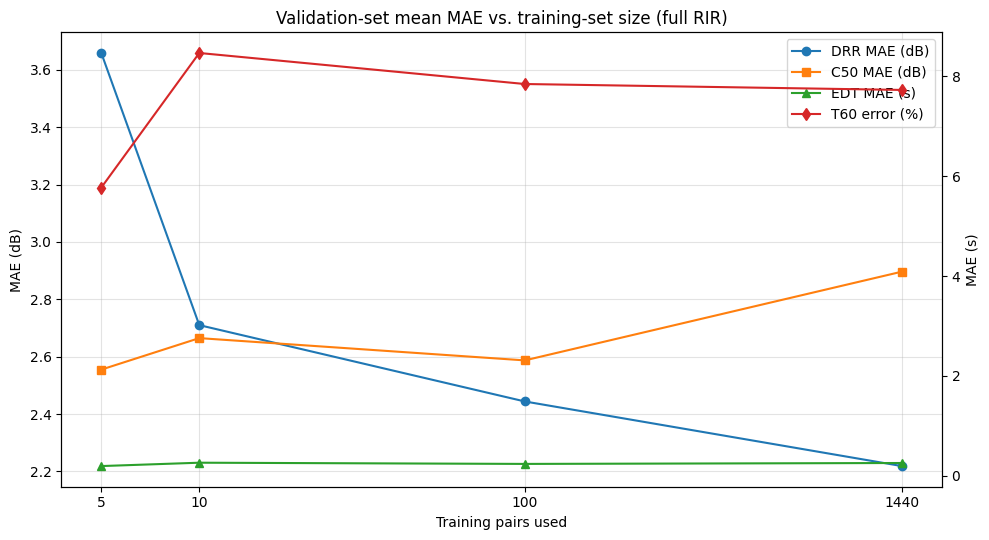

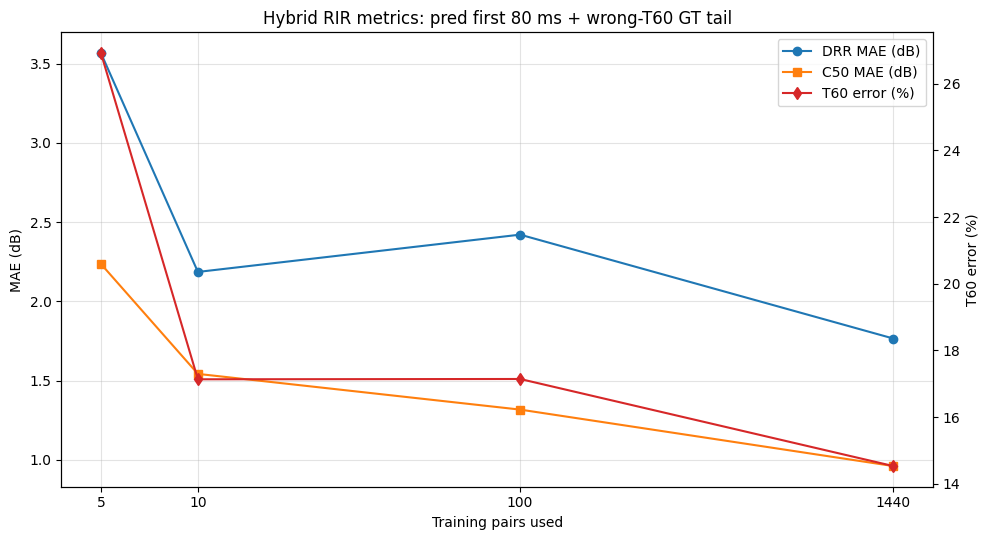

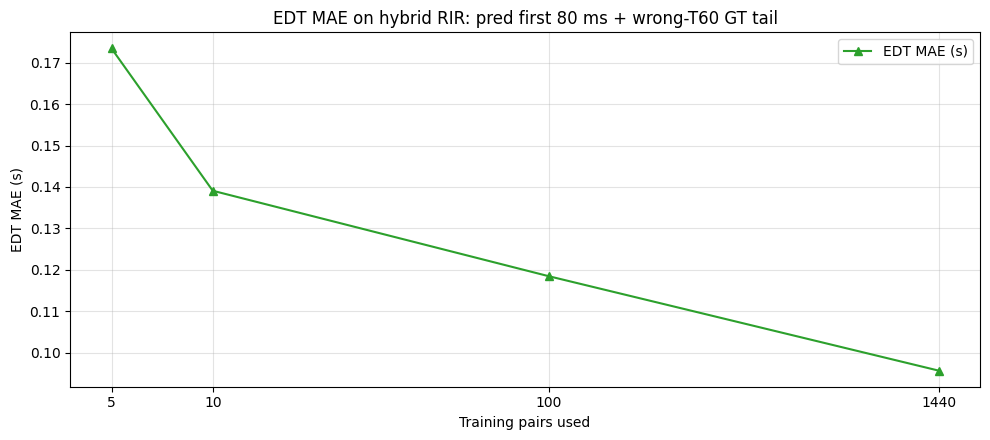

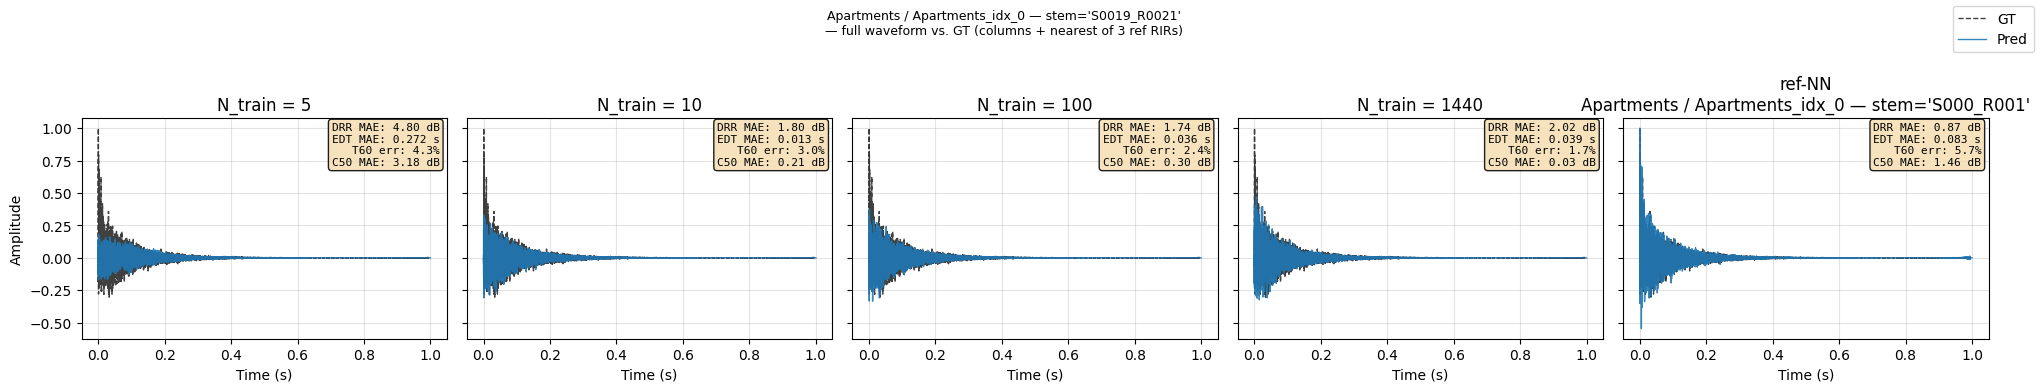

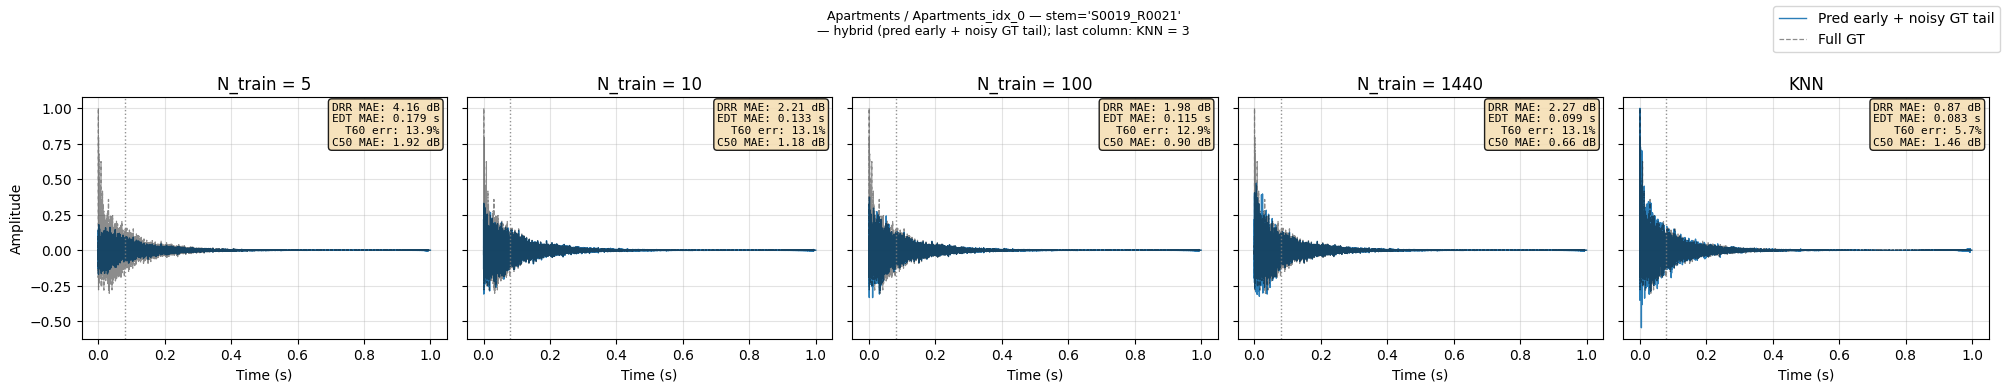

In [17]:
# Ablation plots: four checkpoints × training-set sizes (edit paths below)
from pathlib import Path
from tqdm.auto import tqdm
from matplotlib.ticker import NullLocator

from hybrid_rir_utils import hybrid_pred_gt_tail_wrong_t60
from rir_metrics import t60_percentage_error

# --- (train_pair_count_used, checkpoint_path) — replace with your saved `.ckpt` files ---
ABLATION_CHECKPOINTS = [
    (5, "Models/single_room_best_5.ckpt"),
    (10, "Models/single_room_best_10.ckpt"),
    (100, "Models/single_room_best_100.ckpt"),
    (1440, "Models/single_room_best_1440.ckpt"),
]

# Early-head length used in training / §8 — splice the wrong-T60 GT tail after this point.
ABLATION_HEAD_MS = 80.0
ABLATION_WRONG_T60_SCALE = 1.1
_clip_samples = max(
    1,
    min(int(round(SAMPLE_RATE * ABLATION_HEAD_MS / 1000.0)), WAVEFORM_LENGTH - 1),
)

# Single validation index for waveform graphs (same stem across columns)
ABLATION_WAVEFORM_VAL_IDX = 1

import importlib.util

_comp_ab = Path.cwd() / "Models/training/icassp_lightning_components.py"
_spec_ab = importlib.util.spec_from_file_location("icassp_lightning_components_ab", _comp_ab)
_mod_ab = importlib.util.module_from_spec(_spec_ab)
assert _spec_ab.loader is not None
_spec_ab.loader.exec_module(_mod_ab)
_STFTModel_ab = _mod_ab.STFTModel


def _metrics_drr_edt_c50_t60(pred_wav: np.ndarray, actual_wav: np.ndarray):
    """Absolute errors for DRR, EDT, C50; T60 is percentage error vs GT (same definitions as §8)."""
    pw = np.asarray(pred_wav, dtype=np.float64).flatten()
    aw = np.asarray(actual_wav, dtype=np.float64).flatten()

    def compute_drr(rir, sample_rate=SAMPLE_RATE, direct_ms=5.0):
        rir = np.asarray(rir, dtype=np.float64).flatten()
        direct_samples = int(direct_ms * sample_rate / 1000)
        peak = int(np.abs(rir).argmax())
        direct_energy = np.sum(rir[peak : peak + direct_samples] ** 2) + 1e-10
        reverb_energy = np.sum(rir[peak + direct_samples :] ** 2) + 1e-10
        return float(10 * np.log10(direct_energy / reverb_energy))

    def estimate_edt(rir, sample_rate=SAMPLE_RATE):
        rir = np.asarray(rir, dtype=np.float64).flatten()
        peak = int(np.abs(rir).argmax())
        tail = rir[peak:]
        if len(tail) < 64:
            return float("nan")
        h2 = tail**2
        sch = np.cumsum(h2[::-1])[::-1]
        if sch[0] < 1e-30:
            return float("nan")
        sch_norm = sch / sch[0]
        db = 10.0 * np.log10(np.maximum(sch_norm, 1e-15))
        t = np.arange(len(db)) / float(sample_rate)
        crossing = np.where(db <= -10.0)[0]
        if len(crossing) == 0:
            return float("nan")
        i = int(crossing[0])
        if i == 0:
            t10 = float(t[0])
        else:
            t10 = float(np.interp(-10.0, db[i - 1 : i + 1], t[i - 1 : i + 1]))
        if not np.isfinite(t10):
            return float("nan")
        return float(np.clip(6.908 * t10, 0.02, 10.0))

    def estimate_c50(rir, sample_rate=SAMPLE_RATE, split_ms=50.0):
        rir = np.asarray(rir, dtype=np.float64).flatten()
        peak = int(np.abs(rir).argmax())
        split = peak + int(split_ms * sample_rate / 1000.0)
        split = min(max(split, peak + 1), len(rir))
        early = np.sum(rir[peak:split] ** 2)
        late = np.sum(rir[split:] ** 2) + 1e-20
        return float(10.0 * np.log10(early / late + 1e-20))

    drr_e = abs(compute_drr(pw) - compute_drr(aw))
    t60_e = t60_percentage_error(pw, aw, SAMPLE_RATE)
    edt_p, edt_a = estimate_edt(pw), estimate_edt(aw)
    edt_e = abs(edt_p - edt_a) if np.isfinite(edt_p) and np.isfinite(edt_a) else np.nan
    c50_p, c50_a = estimate_c50(pw), estimate_c50(aw)
    c50_e = abs(c50_p - c50_a) if np.isfinite(c50_p) and np.isfinite(c50_a) else np.nan
    return drr_e, edt_e, c50_e, t60_e


def _forward_to_waveforms(model, sample):
    dev = next(model.parameters()).device
    if USE_DEPTH_MAP:
        X, y, ref, depth, dist_m = sample
        X_b = X.unsqueeze(0).to(dev)
        ref_b = ref.unsqueeze(0).to(dev)
        depth_b = depth.unsqueeze(0).to(dev)
        dist_b = dist_m.unsqueeze(0).to(dev)
        with torch.no_grad():
            pred = model(X_b, ref_b, depth_b, dist_m=dist_b)
    else:
        X, y, ref, dist_m = sample
        X_b = X.unsqueeze(0).to(dev)
        ref_b = ref.unsqueeze(0).to(dev)
        dist_b = dist_m.unsqueeze(0).to(dev)
        with torch.no_grad():
            pred = model(X_b, ref_b, dist_m=dist_b)
    y_np = y.detach().cpu().numpy().flatten()
    pr_np = pred.detach().cpu().numpy().flatten()
    if USE_RAW_WAVEFORMS:
        return pr_np.astype(np.float32), y_np.astype(np.float32)
    from inference_edcModelPytorchLighteningV3 import reconstruct_waveform_from_stft

    stft_freq_bins = STFT_N_FFT // 2 + 1
    stft_time_frames = int(np.ceil(WAVEFORM_LENGTH / float(STFT_HOP)))
    gt_mag = y_np.reshape(stft_freq_bins, stft_time_frames)
    pr_mag = pr_np.reshape(stft_freq_bins, stft_time_frames)
    actual_wav = reconstruct_waveform_from_stft(gt_mag, SAMPLE_RATE, STFT_N_FFT, STFT_HOP)
    pred_wav = reconstruct_waveform_from_stft(pr_mag, SAMPLE_RATE, STFT_N_FFT, STFT_HOP)
    return pred_wav, actual_wav


def _edt_t60_c50_stat_box(ax, pred_wav: np.ndarray, actual_wav: np.ndarray):
    """Overlay DRR / EDT / T60 / C50 metrics (same estimators as §8)."""
    drr_e, edt_e, c50_e, t60_e = _metrics_drr_edt_c50_t60(pred_wav, actual_wav)
    lines = [
        f"DRR MAE: {drr_e:.2f} dB" if np.isfinite(drr_e) else "DRR MAE: n/a",
        f"EDT MAE: {edt_e:.3f} s" if np.isfinite(edt_e) else "EDT MAE: n/a",
        f"T60 err: {t60_e:.1f}%" if np.isfinite(t60_e) else "T60 err: n/a",
        f"C50 MAE: {c50_e:.2f} dB" if np.isfinite(c50_e) else "C50 MAE: n/a",
    ]
    ax.text(
        0.98,
        0.98,
        chr(10).join(lines),
        transform=ax.transAxes,
        va="top",
        ha="right",
        fontsize=8,
        family="monospace",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.88),
    )


if val_ds is None or len(val_ds) == 0:
    raise RuntimeError("Ablation requires a non-empty val_ds — adjust TRAIN_FRACTION / room.")

ABLATION_WAVEFORM_VAL_IDX = int(np.clip(ABLATION_WAVEFORM_VAL_IDX, 0, len(val_ds) - 1))

train_sizes = []
mean_drr, mean_edt, mean_c50, mean_t60 = [], [], [], []
mean_drr_c, mean_edt_c, mean_c50_c, mean_t60_c = [], [], [], []
models_cache = []

map_dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for n_train, ckpt_path in ABLATION_CHECKPOINTS:
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.is_file():
        print(f"Skip missing checkpoint: {ckpt_path}")
        continue
    model_ab = _STFTModel_ab.load_from_checkpoint(str(ckpt_path), map_location=map_dev)
    model_ab.eval()
    models_cache.append((n_train, ckpt_path, model_ab))

    drr_acc, edt_acc, c50_acc, t60_acc = [], [], [], []
    drr_acc_c, edt_acc_c, c50_acc_c, t60_acc_c = [], [], [], []
    for vi in tqdm(range(len(val_ds)), desc=f"val N={n_train}"):
        sample = val_ds[vi]
        pw, aw = _forward_to_waveforms(model_ab, sample)
        L = min(len(pw), len(aw))
        pw, aw = pw[:L], aw[:L]
        d, e, c, t_m = _metrics_drr_edt_c50_t60(pw, aw)
        drr_acc.append(d)
        edt_acc.append(e)
        c50_acc.append(c)
        t60_acc.append(t_m)

        hc = min(_clip_samples, L)
        hybrid_c = hybrid_pred_gt_tail_wrong_t60(
            pw,
            aw,
            hc,
            t60_scale=ABLATION_WRONG_T60_SCALE,
        )
        d2, e2, c2, t2 = _metrics_drr_edt_c50_t60(hybrid_c, aw)
        drr_acc_c.append(d2)
        edt_acc_c.append(e2)
        c50_acc_c.append(c2)
        t60_acc_c.append(t2)

    train_sizes.append(n_train)
    mean_drr.append(np.nanmean(drr_acc))
    mean_edt.append(np.nanmean(edt_acc))
    mean_c50.append(np.nanmean(c50_acc))
    mean_t60.append(np.nanmean(t60_acc))
    mean_drr_c.append(np.nanmean(drr_acc_c))
    mean_edt_c.append(np.nanmean(edt_acc_c))
    mean_c50_c.append(np.nanmean(c50_acc_c))
    mean_t60_c.append(np.nanmean(t60_acc_c))

if not train_sizes:
    raise RuntimeError("No valid checkpoints — update ABLATION_CHECKPOINTS paths.")

train_sizes = np.asarray(train_sizes, dtype=float)
mean_drr = np.asarray(mean_drr)
mean_edt = np.asarray(mean_edt)
mean_c50 = np.asarray(mean_c50)
mean_t60 = np.asarray(mean_t60)
mean_drr_c = np.asarray(mean_drr_c)
mean_edt_c = np.asarray(mean_edt_c)
mean_c50_c = np.asarray(mean_c50_c)
mean_t60_c = np.asarray(mean_t60_c)

# ----- Graph 1: four MAEs on full RIR, log-spaced x with plain numeric tick labels
fig1, ax_db = plt.subplots(figsize=(10, 5.5))
ax_s = ax_db.twinx()
ax_db.set_xscale("log")

(l1,) = ax_db.plot(train_sizes, mean_drr, "o-", label="DRR MAE (dB)", color="C0")
(l2,) = ax_db.plot(train_sizes, mean_c50, "s-", label="C50 MAE (dB)", color="C1")
(l3,) = ax_s.plot(train_sizes, mean_edt, "^-", label="EDT MAE (s)", color="C2")
(l4,) = ax_s.plot(train_sizes, mean_t60, "d-", label="T60 error (%)", color="C3")

ax_db.set_xticks(train_sizes)
ax_db.set_xticklabels([str(int(x)) for x in train_sizes])
ax_db.xaxis.set_minor_locator(NullLocator())

ax_db.set_xlabel("Training pairs used")
ax_db.set_ylabel("MAE (dB)")
ax_s.set_ylabel("MAE (s)")
ax_db.set_title("Validation-set mean MAE vs. training-set size (full RIR)")
lines = [l1, l2, l3, l4]
labs = [ln.get_label() for ln in lines]
ax_db.legend(lines, labs, loc="best")
ax_db.grid(True, which="both", alpha=0.35)
fig1.tight_layout()
plt.show()

# ----- Graph 2: same metrics on the graph-4 hybrid (pred head + wrong-T60 GT tail)
fig1b, ax_db_b = plt.subplots(figsize=(10, 5.5))
ax_pct_b = ax_db_b.twinx()
ax_db_b.set_xscale("log")

(l1b,) = ax_db_b.plot(train_sizes, mean_drr_c, "o-", label="DRR MAE (dB)", color="C0")
(l2b,) = ax_db_b.plot(train_sizes, mean_c50_c, "s-", label="C50 MAE (dB)", color="C1")
(l4b,) = ax_pct_b.plot(train_sizes, mean_t60_c, "d-", label="T60 error (%)", color="C3")

ax_db_b.set_xticks(train_sizes)
ax_db_b.set_xticklabels([str(int(x)) for x in train_sizes])
ax_db_b.xaxis.set_minor_locator(NullLocator())

ax_db_b.set_xlabel("Training pairs used")
ax_db_b.set_ylabel("MAE (dB)")
ax_pct_b.set_ylabel("T60 error (%)")
ax_db_b.set_title(
    f"Hybrid RIR metrics: pred first {ABLATION_HEAD_MS:.0f} ms + wrong-T60 GT tail"
)
lines_b = [l1b, l2b, l4b]
labs_b = [ln.get_label() for ln in lines_b]
ax_db_b.legend(lines_b, labs_b, loc="best")
ax_db_b.grid(True, which="both", alpha=0.35)
fig1b.tight_layout()
plt.show()

# ----- Graph 2b: EDT MAE on the same graph-4 hybrid, separated because of its smaller scale
fig1b_edt, ax_edt_b = plt.subplots(figsize=(10, 4.5))
ax_edt_b.set_xscale("log")
ax_edt_b.plot(train_sizes, mean_edt_c, "^-", label="EDT MAE (s)", color="C2")
ax_edt_b.set_xticks(train_sizes)
ax_edt_b.set_xticklabels([str(int(x)) for x in train_sizes])
ax_edt_b.xaxis.set_minor_locator(NullLocator())
ax_edt_b.set_xlabel("Training pairs used")
ax_edt_b.set_ylabel("EDT MAE (s)")
ax_edt_b.set_title(
    f"EDT MAE on hybrid RIR: pred first {ABLATION_HEAD_MS:.0f} ms + wrong-T60 GT tail"
)
ax_edt_b.legend(loc="best")
ax_edt_b.grid(True, which="both", alpha=0.35)
fig1b_edt.tight_layout()
plt.show()

# ----- Graph 3: same val sample full waveform + ref-RIR baseline (nearest of 3 model refs)
sample_demo = val_ds[ABLATION_WAVEFORM_VAL_IDX]
if hasattr(val_ds, "indices"):
    gi = int(val_ds.indices[ABLATION_WAVEFORM_VAL_IDX])
else:
    gi = int(ABLATION_WAVEFORM_VAL_IDX)
_row_demo = room_df.iloc[gi]
_demo_room_label = (
    f"{_row_demo['room_type']} / {_row_demo['room_id']} — stem={_row_demo['stem']!r}"
)

pred_demo0, actual_demo = _forward_to_waveforms(models_cache[0][2], sample_demo)
L_demo = min(len(pred_demo0), len(actual_demo))
_t_clip = min(_clip_samples, L_demo)
_t_sec = _t_clip / float(SAMPLE_RATE)

if full_ds is None:
    raise RuntimeError("Ref-RIR baseline needs full_ds from §4–§5.")

_k_ref = min(N_REF_RIRS, len(room_df))
_ref_pick = room_df.sort_values("stem").head(_k_ref) if USE_REFERENCE_RIRS else room_df.head(_k_ref)
ref_ilocs = []
for _, rr in _ref_pick.iterrows():
    hit = np.flatnonzero(room_df["stem"].values == rr["stem"])
    ref_ilocs.append(int(hit[0]))

X_nn_ab = np.concatenate(
    [
        full_ds.X.numpy().reshape(len(full_ds), -1),
        full_ds.dist_m.numpy().reshape(len(full_ds), -1),
    ],
    axis=1,
).astype(np.float64)
_val_glob_ab = int(val_ds.indices[ABLATION_WAVEFORM_VAL_IDX])
q = X_nn_ab[_val_glob_ab : _val_glob_ab + 1]
X_refs = X_nn_ab[ref_ilocs]
dists = np.linalg.norm(X_refs - q, axis=1)
_best_ref = int(np.argmin(dists))
nn_wave_ablation = full_ds.y[ref_ilocs[_best_ref]].numpy().flatten().astype(np.float32)
_row_nn_ab = room_df.iloc[ref_ilocs[_best_ref]]
# _nn_ab_room_label = (
#     f"{_row_nn_ab['room_type']} / {_row_nn_ab['room_id']} — stem={_row_nn_ab['stem']!r}\n{_row_nn_ab['rir_path']}"
# )

_nn_ab_room_label = (
    f"{_row_nn_ab['room_type']} / {_row_nn_ab['room_id']} — stem={_row_nn_ab['stem']!r}"
)

_n_ab_cols = len(models_cache) + 1
fig2, axes2 = plt.subplots(1, _n_ab_cols, figsize=(4 * _n_ab_cols, 3.8), sharey=True)
if _n_ab_cols == 1:
    axes2 = [axes2]

_ab_panels = []
for (n_train, ckpt_path, model_ab) in models_cache:
    pred_w, _aw = _forward_to_waveforms(model_ab, sample_demo)
    _ab_panels.append((f"N_train = {n_train}", np.asarray(pred_w, dtype=np.float32).flatten()))
_ab_panels.append((f"ref-NN\n{_nn_ab_room_label}", nn_wave_ablation))

for ax, (ptitle, pred_w) in zip(axes2, _ab_panels):
    actual_w = np.asarray(actual_demo, dtype=np.float32).flatten()
    L = min(len(pred_w), len(actual_w))
    pred_w = pred_w[:L]
    actual_w = actual_w[:L]
    t = np.arange(L) / float(SAMPLE_RATE)
    ax.plot(t, actual_w, "k--", linewidth=1.0, alpha=0.75, label="GT")
    ax.plot(t, pred_w, linewidth=1.0, alpha=0.9, label="Pred")
    ax.set_title(ptitle)
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.35)
    _edt_t60_c50_stat_box(ax, pred_w, actual_w)
axes2[0].set_ylabel("Amplitude")
handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc="upper right")
fig2.suptitle(
    f"{_demo_room_label}\n— full waveform vs. GT (columns + nearest of 3 ref RIRs)",
    y=1.02,
    fontsize=9,
)
fig2.tight_layout()
plt.show()

# ----- Graph 4: hybrid (early pred + RMS-matched GT tail); ref-NN column = full neighbor waveform (no GT splice)

actual_flat_ab = np.asarray(actual_demo, dtype=np.float32).flatten()
fig3, axes3 = plt.subplots(1, _n_ab_cols, figsize=(4 * _n_ab_cols, 3.8), sharey=True)
if _n_ab_cols == 1:
    axes3 = [axes3]

_hybrid_panels = []
for (n_train, ckpt_path, model_ab) in models_cache:
    pred_w, actual_w = _forward_to_waveforms(model_ab, sample_demo)
    Lc = min(len(pred_w), len(actual_w), len(actual_flat_ab))
    pred_w = pred_w[:Lc]
    actual_w = actual_w[:Lc]
    h = min(_clip_samples, Lc)
    hybrid = hybrid_pred_gt_tail_wrong_t60(
        pred_w,
        actual_w,
        h,
        t60_scale=ABLATION_WRONG_T60_SCALE,
    )
    _hybrid_panels.append((f"N_train = {n_train}", hybrid, Lc))

Lc_nn = min(len(nn_wave_ablation), len(actual_flat_ab))
nn_full_ab = nn_wave_ablation[:Lc_nn].astype(np.float64)
_hybrid_panels.append((f"KNN", nn_full_ab, Lc_nn))

for ax, (ptitle, hybrid, Lc) in zip(axes3, _hybrid_panels):
    actual_w = actual_flat_ab[:Lc]
    t_h = np.arange(len(hybrid)) / float(SAMPLE_RATE)
    _lbl = (
        "Full ref-NN waveform"
        if "ref-NN" in ptitle
        else "Pred early + noisy GT tail"
    )
    ax.plot(t_h, hybrid, linewidth=1.0, alpha=0.95, color="C0", label=_lbl)
    ax.plot(np.arange(Lc) / float(SAMPLE_RATE), actual_w, "k--", linewidth=0.9, alpha=0.45, label="Full GT")
    if "ref-NN" not in ptitle:
        ax.axvline(_t_sec, color="gray", linestyle=":", linewidth=1.0, alpha=0.85)
    ax.set_title(ptitle)
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.35)
    _edt_t60_c50_stat_box(ax, hybrid.astype(np.float32), actual_w)
axes3[0].set_ylabel("Amplitude")
handles3, labels3 = axes3[0].get_legend_handles_labels()
fig3.legend(handles3, labels3, loc="upper right")
fig3.suptitle(
    f"{_demo_room_label}\n— hybrid (pred early + noisy GT tail); last column: KNN = 3",
    y=1.02,
    fontsize=9,
)
fig3.tight_layout()
plt.show()
